# Practice CNN Architecture

## Getting the Dataset
- Dataset Link: !wget https://app.roboflow.com/computer-vision-2v7mb/crowd-counting-dataset-w3o7w-l8c0s/1/images

In [ ]:
# !pip install roboflow

# from roboflow import Roboflow
# rf = Roboflow(api_key="lsXqkr4nP217WxcbT5nC")
# project = rf.workspace("computer-vision-2v7mb").project("crowd-counting-dataset-w3o7w-l8c0s")
# version = project.version(1)
# dataset = version.download("yolov11")


### Content in Data Direcctory

In [ ]:
import os

for dirpath, dirnames, filenames in os.walk("crowd-counting-dataset-1"):
    print(f"There are {len(dirnames)} directories and {len(filenames)} files in {dirpath}")

There are 3 directories and 3 files in crowd-counting-dataset-1
There are 2 directories and 0 files in crowd-counting-dataset-1/valid
There are 0 directories and 382 files in crowd-counting-dataset-1/valid/images
There are 0 directories and 382 files in crowd-counting-dataset-1/valid/labels
There are 2 directories and 0 files in crowd-counting-dataset-1/test
There are 0 directories and 231 files in crowd-counting-dataset-1/test/images
There are 0 directories and 231 files in crowd-counting-dataset-1/test/labels
There are 2 directories and 0 files in crowd-counting-dataset-1/train
There are 0 directories and 2285 files in crowd-counting-dataset-1/train/images
There are 0 directories and 2285 files in crowd-counting-dataset-1/train/labels


## Transforming the Labels

In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from PIL import Image

IMAGE_SIZE = (400, 400)
BATCH_SIZE = 16  # Reduce this if it still crashes

# ADD — replace old label_to_matrix
from scipy.ndimage import gaussian_filter

def label_to_matrix(label_path, image_size=IMAGE_SIZE):
    matrix = np.zeros(image_size, dtype=np.float32)

    if os.path.getsize(label_path.numpy().decode()) == 0:
        return matrix[..., np.newaxis]

    label = pd.read_csv(label_path.numpy().decode(), sep=' ', header=None)
    points = (label[[1, 2]].values * image_size[0]).astype(int)
    points = np.clip(points, 0, image_size[0] - 1)
    matrix[points[:, 1], points[:, 0]] = 1.0

    matrix = gaussian_filter(matrix, sigma=3)          # spread the point
    if matrix.max() > 0:
        matrix = matrix / matrix.max()                 # renormalize to [0,1]

    return matrix[..., np.newaxis]


def load_sample(img_path, label_path):
    """Lazily load a single image-label pair — called per sample, not all at once."""

    # --- Image ---
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMAGE_SIZE)
    img = tf.cast(img, tf.float32) / 255.0  # (400, 400, 3)

    # --- Label matrix ---
    matrix = tf.py_function(
        func=label_to_matrix,
        inp=[label_path],
        Tout=tf.float32
    )
    matrix.set_shape([*IMAGE_SIZE, 1])  # (400, 400, 1)

    return img, matrix


def make_tf_dataset(image_dir, label_dir, batch_size=BATCH_SIZE, shuffle=True):
    # Build paired file path lists
    image_files = sorted([
        f for f in os.listdir(image_dir) if f.endswith('.jpg')
    ])

    img_paths, lbl_paths = [], []
    for fname in image_files:
        lbl_fname = fname.replace('.jpg', '.txt')
        lbl_path  = os.path.join(label_dir, lbl_fname)
        if os.path.exists(lbl_path):
            img_paths.append(os.path.join(image_dir, fname))
            lbl_paths.append(lbl_path)

    print(f"Found {len(img_paths)} samples in {image_dir}")

    dataset = tf.data.Dataset.from_tensor_slices((img_paths, lbl_paths))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=200, reshuffle_each_iteration=True)

    dataset = (dataset
               .map(load_sample, num_parallel_calls=tf.data.AUTOTUNE)
               .batch(batch_size)
               .prefetch(tf.data.AUTOTUNE))

    return dataset


# --- Build datasets ---
BASE = 'crowd-counting-dataset-1'

train_ds = make_tf_dataset(f'{BASE}/train/images', f'{BASE}/train/labels', shuffle=True)
valid_ds = make_tf_dataset(f'{BASE}/valid/images', f'{BASE}/valid/labels', shuffle=False)
test_ds  = make_tf_dataset(f'{BASE}/test/images',  f'{BASE}/test/labels',  shuffle=False)

# --- Verify ---
for images, labels in train_ds.take(1):
    print("Image batch:", images.shape)   # (16, 400, 400, 3)
    print("Label batch:", labels.shape)   # (16, 400, 400, 1)

Found 2285 samples in crowd-counting-dataset-1/train/images
Found 382 samples in crowd-counting-dataset-1/valid/images
Found 231 samples in crowd-counting-dataset-1/test/images
Image batch: (16, 400, 400, 3)
Label batch: (16, 400, 400, 1)


### Get and Check Random Image

In [ ]:
def visualize_sample(dataset, title='Sample'):
    # Grab a random batch then pick a random index within it
    for images, labels in dataset.take(1):
        idx = np.random.randint(0, images.shape[0])

        single_img = images[idx].numpy()             # (400, 400, 3)
        single_lbl = labels[idx].numpy().squeeze()   # (400, 400)

    # Get center point coordinates from the label matrix
    y_coords, x_coords = np.where(single_lbl == 1)

    fig, ax = plt.subplots(figsize=(8, 8))

    ax.imshow(single_img, extent=[0, 400, 400, 0])
    ax.scatter(x_coords, y_coords, c='red', s=10, marker='x', label=f'Detections: {len(x_coords)}')

    ax.set_xlim(0, 400)
    ax.set_ylim(400, 0)
    ax.legend()
    ax.set_title(f'{title} — {len(x_coords)} detections')
    plt.tight_layout()
    plt.show()


# Usage
# visualize_sample(train_ds, title='Train')
# visualize_sample(valid_ds, title='Valid')
# visualize_sample(test_ds,  title='Test')


## CNN Model Training
- Load our images
- Preprocess
- Build a CNN to find patterns
- Compile CNN
- Fit To our training data

### Building the CNN model

In [ ]:
# U-Net with skip connections
inputs = tf.keras.Input(shape=(400, 400, 3))

# Encoder
e1 = tf.keras.layers.Conv2D(16, 3, activation="relu", padding='same')(inputs)
p1 = tf.keras.layers.MaxPool2D(2)(e1)          # 200x200

e2 = tf.keras.layers.Conv2D(32, 3, activation="relu", padding='same')(p1)
p2 = tf.keras.layers.MaxPool2D(2)(e2)          # 100x100

e3 = tf.keras.layers.Conv2D(64, 3, activation="relu", padding='same')(p2)
p3 = tf.keras.layers.MaxPool2D(2)(e3)          # 50x50

# Bottleneck
b = tf.keras.layers.Conv2D(128, 3, activation="relu", padding='same')(p3)

# Decoder + skip connections
d3 = tf.keras.layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu')(b)
d3 = tf.keras.layers.Concatenate()([d3, e3])   # skip from e3

d2 = tf.keras.layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu')(d3)
d2 = tf.keras.layers.Concatenate()([d2, e2])   # skip from e2

d1 = tf.keras.layers.Conv2DTranspose(16, 3, strides=2, padding='same', activation='relu')(d2)
d1 = tf.keras.layers.Concatenate()([d1, e1])   # skip from e1

outputs = tf.keras.layers.Conv2D(1, 1, activation='sigmoid', padding='same')(d1)

model_1 = tf.keras.Model(inputs, outputs)

def weighted_focal_loss(gamma=2.0, pos_weight=1000.0):
    bce = tf.keras.losses.BinaryFocalCrossentropy(gamma=gamma)
    def loss(y_true, y_pred):
        weights = 1.0 + y_true * (pos_weight - 1.0)  # upweight positives
        return tf.reduce_mean(bce(y_true, y_pred) * tf.squeeze(weights, -1))
    return loss

model_1.compile(
    loss=weighted_focal_loss(gamma=2.0, pos_weight=200.0),
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[
        tf.keras.metrics.Precision(thresholds=0.1),
        tf.keras.metrics.Recall(thresholds=0.1)
    ]
)

model_1.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 400, 400,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 400, 400,  │        448 │ input_layer_2[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 200, 200,  │          0 │ conv2d_8[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 200, 200,  │      4,640 │ max_pooling2d_6[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 100, 100,  │          0 │ conv2d_9[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 100, 100,  │     18,496 │ max_pooling2d_7[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 50, 50,    │          0 │ conv2d_10[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 50, 50,    │     73,856 │ max_pooling2d_8[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_6  │ (None, 100, 100,  │     73,792 │ conv2d_11[0][0]   │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 100, 100,  │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 128)              │            │ conv2d_10[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_7  │ (None, 200, 200,  │     36,896 │ concatenate[0][0] │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 200, 200,  │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 64)               │            │ conv2d_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_8  │ (None, 400, 400,  │      9,232 │ concatenate_1[0]… │
│ (Conv2DTranspose)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 400, 400,  │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 32)               │            │ conv2d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 400, 400,  │         33 │ concatenate_2[0]… │
│                     │ 1)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 217,393 (849.19 KB)

 Trainable params: 217,393 (849.19 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# NEW
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_recall',
    patience=5,
    restore_best_weights=True,
    mode='max'
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_recall',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    mode='max'
)

history = model_1.fit(
    train_ds,
    epochs=30,                          # let early stopping decide when to stop
    steps_per_epoch=len(train_ds),
    validation_data=valid_ds,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 35s 246ms/step - loss: 0.1134 - precision_2: 0.1591 - recall_2: 1.0065e-05 - val_loss: 0.1356 - val_precision_2: 0.0000e+00 - val_recall_2: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/30


Early stopping conditioned on metric `val_recall` which is not available. Available metrics are: loss,precision_2,recall_2,val_loss,val_precision_2,val_recall_2
Learning rate reduction is conditioned on metric `val_recall` which is not available. Available metrics are: loss,precision_2,recall_2,val_loss,val_precision_2,val_recall_2,learning_rate.


143/143 ━━━━━━━━━━━━━━━━━━━━ 35s 243ms/step - loss: 0.1122 - precision_2: 0.0000e+00 - recall_2: 0.0000e+00 - val_loss: 0.1268 - val_precision_2: 0.0000e+00 - val_recall_2: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/30


Early stopping conditioned on metric `val_recall` which is not available. Available metrics are: loss,precision_2,recall_2,val_loss,val_precision_2,val_recall_2
Learning rate reduction is conditioned on metric `val_recall` which is not available. Available metrics are: loss,precision_2,recall_2,val_loss,val_precision_2,val_recall_2,learning_rate.


143/143 ━━━━━━━━━━━━━━━━━━━━ 37s 260ms/step - loss: 0.1095 - precision_2: 0.0000e+00 - recall_2: 0.0000e+00 - val_loss: 0.1256 - val_precision_2: 0.0000e+00 - val_recall_2: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/30


...

Early stopping conditioned on metric `val_recall` which is not available. Available metrics are: loss,precision_2,recall_2,val_loss,val_precision_2,val_recall_2
Learning rate reduction is conditioned on metric `val_recall` which is not available. Available metrics are: loss,precision_2,recall_2,val_loss,val_precision_2,val_recall_2,learning_rate.


143/143 ━━━━━━━━━━━━━━━━━━━━ 41s 259ms/step - loss: 0.0977 - precision_2: 0.9285 - recall_2: 0.0191 - val_loss: 0.1144 - val_precision_2: 0.9371 - val_recall_2: 0.0167 - learning_rate: 0.0010
Epoch 30/30


Early stopping conditioned on metric `val_recall` which is not available. Available metrics are: loss,precision_2,recall_2,val_loss,val_precision_2,val_recall_2
Learning rate reduction is conditioned on metric `val_recall` which is not available. Available metrics are: loss,precision_2,recall_2,val_loss,val_precision_2,val_recall_2,learning_rate.


143/143 ━━━━━━━━━━━━━━━━━━━━ 36s 249ms/step - loss: 0.0976 - precision_2: 0.9248 - recall_2: 0.0193 - val_loss: 0.1150 - val_precision_2: 0.8947 - val_recall_2: 0.0290 - learning_rate: 0.0010


Early stopping conditioned on metric `val_recall` which is not available. Available metrics are: loss,precision_2,recall_2,val_loss,val_precision_2,val_recall_2
Learning rate reduction is conditioned on metric `val_recall` which is not available. Available metrics are: loss,precision_2,recall_2,val_loss,val_precision_2,val_recall_2,learning_rate.


In [ ]:
for key, value in history.history.items():
    if key in ('precision_2', 'recall_2', 'val_precision_2', 'val_recall_2'):
        print(key, value)

precision_2 [0.15905173122882843, 0.0, 0.0, 1.0, 0.9707547426223755, 0.9272449612617493, 0.9153595566749573, 0.886075496673584, 0.897925853729248, 0.8961349725723267, 0.8927642703056335, 0.9135257005691528, 0.9149565696716309, 0.9079968333244324, 0.9024109244346619, 0.9156418442726135, 0.9137280583381653, 0.9184696674346924, 0.9129905104637146, 0.9199139475822449, 0.914337694644928, 0.9195478558540344, 0.9207919836044312, 0.9189484715461731, 0.9212245345115662, 0.9259308576583862, 0.9257413148880005, 0.9272222518920898, 0.9284538626670837, 0.9248009920120239]
recall_2 [1.006489219435025e-05, 0.0, 0.0, 9.092040897940024e-09, 9.355712791148107e-06, 3.3140484447358176e-05, 8.436504867859185e-05, 0.000212217346415855, 0.0003601540520321578, 0.0006201865035109222, 0.0007116703782230616, 0.001395119121298194, 0.002143203979358077, 0.002798802684992552, 0.003991270903497934, 0.005215113516896963, 0.007377246860414743, 0.0072774155996739864, 0.009714674204587936, 0.011017103679478168, 0.011928

Text(0.5, 1.0, 'Recall')

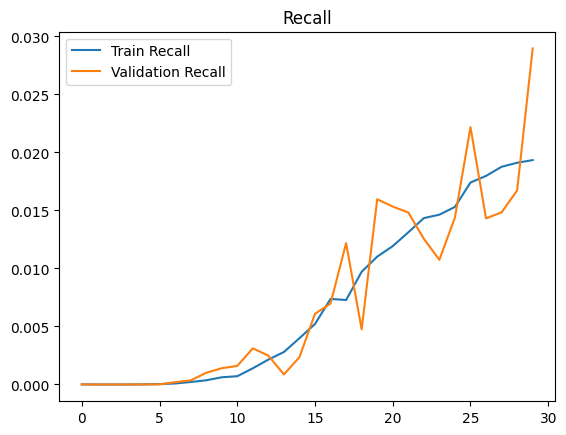

In [ ]:
plt.plot(history.history['recall_2'], label='Train Recall')
plt.plot(history.history['val_recall_2'], label='Validation Recall')
plt.legend()
plt.title('Recall')

Text(0.5, 1.0, 'Precision')

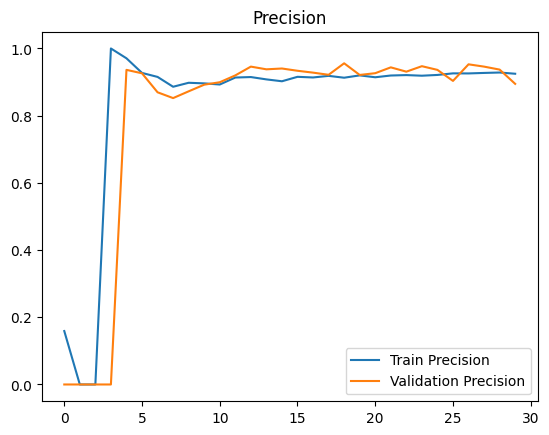

In [ ]:
plt.plot(history.history['precision_2'], label='Train Precision')
plt.plot(history.history['val_precision_2'], label='Validation Precision')
plt.legend()
plt.title('Precision')

## Saving Our Model

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
model_1.save('/content/drive/MyDrive/Stampede_Prediction/model_2.keras')

In [ ]:
model_1 = tf.keras.models.load_model('/content/drive/MyDrive/Stampede_Prediction/model_2.keras')

In [ ]:
def weighted_focal_loss(gamma=2.0, pos_weight=1000.0):
    bce = tf.keras.losses.BinaryFocalCrossentropy(gamma=gamma)
    def loss(y_true, y_pred):
        weights = 1.0 + y_true * (pos_weight - 1.0)  # upweight positives
        return tf.reduce_mean(bce(y_true, y_pred) * tf.squeeze(weights, -1))
    return loss

model_1.compile(
    loss=weighted_focal_loss(gamma=2.0, pos_weight=800.0),
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[
        tf.keras.metrics.Precision(thresholds=0.2),
        tf.keras.metrics.Recall(thresholds=0.2)
    ]
)

In [ ]:
# NEW
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_recall',
    patience=5,
    restore_best_weights=True,
    mode='max'
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_recall',
    factor=0.4,
    patience=3,
    min_lr=1e-6,
    mode='max'
)

history = model_1.fit(
    train_ds,
    epochs=30,                          # let early stopping decide when to stop
    steps_per_epoch=len(train_ds),
    validation_data=valid_ds,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 46s 278ms/step - loss: 0.4357 - precision_5: 0.6211 - recall_5: 0.5497 - val_loss: 0.5180 - val_precision_5: 0.5983 - val_recall_5: 0.6525 - learning_rate: 0.0010
Epoch 2/30


Early stopping conditioned on metric `val_recall` which is not available. Available metrics are: loss,precision_5,recall_5,val_loss,val_precision_5,val_recall_5
Learning rate reduction is conditioned on metric `val_recall` which is not available. Available metrics are: loss,precision_5,recall_5,val_loss,val_precision_5,val_recall_5,learning_rate.


143/143 ━━━━━━━━━━━━━━━━━━━━ 35s 246ms/step - loss: 0.4385 - precision_5: 0.6238 - recall_5: 0.5495 - val_loss: 0.5197 - val_precision_5: 0.7218 - val_recall_5: 0.4820 - learning_rate: 0.0010
Epoch 3/30


Early stopping conditioned on metric `val_recall` which is not available. Available metrics are: loss,precision_5,recall_5,val_loss,val_precision_5,val_recall_5
Learning rate reduction is conditioned on metric `val_recall` which is not available. Available metrics are: loss,precision_5,recall_5,val_loss,val_precision_5,val_recall_5,learning_rate.


143/143 ━━━━━━━━━━━━━━━━━━━━ 36s 253ms/step - loss: 0.4330 - precision_5: 0.6302 - recall_5: 0.5452 - val_loss: 0.5135 - val_precision_5: 0.6315 - val_recall_5: 0.5993 - learning_rate: 0.0010
Epoch 4/30


...

Early stopping conditioned on metric `val_recall` which is not available. Available metrics are: loss,precision_5,recall_5,val_loss,val_precision_5,val_recall_5
Learning rate reduction is conditioned on metric `val_recall` which is not available. Available metrics are: loss,precision_5,recall_5,val_loss,val_precision_5,val_recall_5,learning_rate.


143/143 ━━━━━━━━━━━━━━━━━━━━ 41s 256ms/step - loss: 0.4061 - precision_5: 0.6765 - recall_5: 0.4756 - val_loss: 0.5071 - val_precision_5: 0.6790 - val_recall_5: 0.4983 - learning_rate: 0.0010
Epoch 30/30


Early stopping conditioned on metric `val_recall` which is not available. Available metrics are: loss,precision_5,recall_5,val_loss,val_precision_5,val_recall_5
Learning rate reduction is conditioned on metric `val_recall` which is not available. Available metrics are: loss,precision_5,recall_5,val_loss,val_precision_5,val_recall_5,learning_rate.


143/143 ━━━━━━━━━━━━━━━━━━━━ 38s 264ms/step - loss: 0.4042 - precision_5: 0.6814 - recall_5: 0.4755 - val_loss: 0.5063 - val_precision_5: 0.6755 - val_recall_5: 0.4947 - learning_rate: 0.0010


Early stopping conditioned on metric `val_recall` which is not available. Available metrics are: loss,precision_5,recall_5,val_loss,val_precision_5,val_recall_5
Learning rate reduction is conditioned on metric `val_recall` which is not available. Available metrics are: loss,precision_5,recall_5,val_loss,val_precision_5,val_recall_5,learning_rate.


Text(0.5, 1.0, 'Recall')

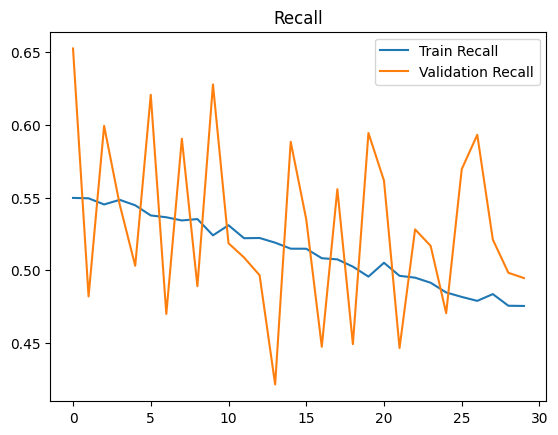

In [ ]:
plt.plot(history.history['recall_5'], label='Train Recall')
plt.plot(history.history['val_recall_5'], label='Validation Recall')
plt.legend()
plt.title('Recall')

Text(0.5, 1.0, 'Precision')

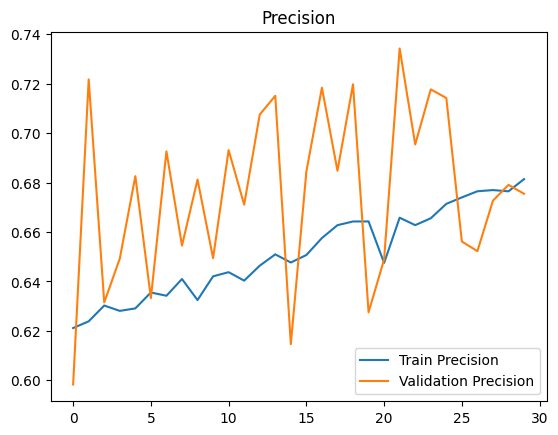

In [ ]:
plt.plot(history.history['precision_5'], label='Train Precision')
plt.plot(history.history['val_precision_5'], label='Validation Precision')
plt.legend()
plt.title('Precision')

In [ ]:
model_1.save('/content/drive/MyDrive/Stampede_Prediction/67_precision49_recall.keras')